# Physics-sensitivity RMSE and VRMSE

Summarize the all-station RMSE and VRMSE distributions for four physics schemes of Typhoons Ragasa and Yagi. The notebook prints full descriptive statistics, station-group mean errors for the Fig6 classifications, and exports one publication-resolution 1 × 2 VRMSE boxplot figure.

In [1]:
from __future__ import annotations

from pathlib import Path
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd


def find_supplementary_dir() -> Path:
    """Locate Supplementary from the repository root or Supplementary itself."""
    cwd = Path.cwd().resolve()
    for candidate in (cwd / "Supplementary", cwd):
        if (candidate / "physics_sensitivity").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not locate Supplementary/physics_sensitivity from {cwd}"
    )


SUPPLEMENTARY_DIR = find_supplementary_dir()
DATA_DIR = SUPPLEMENTARY_DIR / "physics_sensitivity"
PUBLISH_DIR = SUPPLEMENTARY_DIR / "publish"
GROUP_MD = SUPPLEMENTARY_DIR.parent / "Fig6" / "input" / "20260616-两次台风站点分类.md"
PUBLISH_DIR.mkdir(parents=True, exist_ok=True)

DPI = 600
CASE_ORDER = [f"case_{index}" for index in range(1, 5)]
CASE_COLORS = ["#9E9E9E", "#66A182", "#6E8BC3", "#C96A5A"]
METRIC_ORDER = ["RMSE", "VRMSE"]
STORMS = {
    "ragasa": {
        "label": "Ragasa",
        "expected_stations": 30,
        "group_heading": "台风桦加沙站点分类：",
        "group_sizes": [5, 4, 4, 6, 4],
    },
    "yagi": {
        "label": "Yagi",
        "expected_stations": 31,
        "group_heading": "台风摩羯站点分类：",
        "group_sizes": [5, 3, 4, 7, 4],
    },
}

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
FONT_FAMILY = "Arial" if "Arial" in available_fonts else "DejaVu Sans"
mpl.rcParams.update(
    {
        "font.family": FONT_FAMILY,
        "font.sans-serif": [FONT_FAMILY],
        "font.size": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    }
)

print("[Paths]")
print("  DATA    =", DATA_DIR.resolve())
print("  PUBLISH =", PUBLISH_DIR.resolve())
print("  GROUPS  =", GROUP_MD.resolve())
print("[Font]", FONT_FAMILY)

[Paths]
  DATA    = E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Supplementary\physics_sensitivity
  PUBLISH = E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Supplementary\publish
  GROUPS  = E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\input\20260616-两次台风站点分类.md
[Font] Arial


In [2]:
def load_metric_table(storm_key: str, metric: str) -> pd.DataFrame:
    """Load and validate one case-by-station metric table."""
    path = (
        DATA_DIR
        / f"sensitivity_{storm_key}"
        / f"uv_{metric.lower()}_sensitivity.csv"
    )
    if not path.is_file():
        raise FileNotFoundError(f"Missing input file: {path}")

    raw = pd.read_csv(path)
    if "case" not in raw.columns:
        raise ValueError(f"Missing 'case' column in {path}")
    if raw["case"].duplicated().any():
        duplicates = raw.loc[raw["case"].duplicated(), "case"].tolist()
        raise ValueError(f"Duplicate cases in {path}: {duplicates}")

    table = raw.set_index("case")
    if table.index.tolist() != CASE_ORDER:
        raise ValueError(
            f"Expected cases {CASE_ORDER} in {path}; found {table.index.tolist()}"
        )
    if table.columns.duplicated().any():
        duplicates = table.columns[table.columns.duplicated()].tolist()
        raise ValueError(f"Duplicate station columns in {path}: {duplicates}")

    numeric = table.apply(pd.to_numeric, errors="coerce")
    invalid = ~np.isfinite(numeric.to_numpy(dtype=float))
    if invalid.any():
        rows, columns = np.where(invalid)
        locations = [
            f"{numeric.index[row]}/{numeric.columns[column]}"
            for row, column in zip(rows[:10], columns[:10])
        ]
        raise ValueError(f"Missing or non-finite values in {path}: {locations}")
    if (numeric.to_numpy(dtype=float) < 0).any():
        raise ValueError(f"Negative {metric} value found in {path}")
    return numeric


storm_data: dict[str, dict[str, pd.DataFrame]] = {}
for storm_key, metadata in STORMS.items():
    metric_tables = {
        metric: load_metric_table(storm_key, metric)
        for metric in METRIC_ORDER
    }
    rmse_stations = metric_tables["RMSE"].columns.tolist()
    vrmse_stations = metric_tables["VRMSE"].columns.tolist()
    if rmse_stations != vrmse_stations:
        raise ValueError(f"RMSE/VRMSE station order differs for {storm_key}")
    if len(rmse_stations) != metadata["expected_stations"]:
        raise ValueError(
            f"Expected {metadata['expected_stations']} stations for "
            f"{metadata['label']}; found {len(rmse_stations)}"
        )
    storm_data[storm_key] = metric_tables
    print(
        f"[Validated] {metadata['label']}: {len(rmse_stations)} stations, "
        f"{len(CASE_ORDER)} cases, {len(METRIC_ORDER)} metrics"
    )

[Validated] Ragasa: 30 stations, 4 cases, 2 metrics


[Validated] Yagi: 31 stations, 4 cases, 2 metrics


In [3]:
STAT_COLUMNS = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
summary_parts: list[pd.DataFrame] = []

for storm_key, metadata in STORMS.items():
    for metric in METRIC_ORDER:
        statistics = (
            storm_data[storm_key][metric]
            .T.describe()
            .T[STAT_COLUMNS]
            .rename_axis("case")
            .reset_index()
        )
        statistics.insert(0, "metric", metric)
        statistics.insert(0, "storm", metadata["label"])
        summary_parts.append(statistics)

summary = pd.concat(summary_parts, ignore_index=True)
if len(summary) != len(STORMS) * len(METRIC_ORDER) * len(CASE_ORDER):
    raise RuntimeError(f"Expected 16 summary rows; found {len(summary)}")

summary_display = summary.copy()
summary_display["count"] = summary_display["count"].astype(int)
summary_display[STAT_COLUMNS[1:]] = summary_display[STAT_COLUMNS[1:]].round(3)

for storm_label in [metadata["label"] for metadata in STORMS.values()]:
    for metric in METRIC_ORDER:
        block = summary_display.loc[
            (summary_display["storm"] == storm_label)
            & (summary_display["metric"] == metric),
            ["case", *STAT_COLUMNS],
        ]
        print(f"\n[{storm_label} - {metric}]")
        print(block.to_string(index=False))

summary_display


[Ragasa - RMSE]
  case  count   mean   std   min   25%    50%    75%    max
case_1     30  6.772 2.790 3.579 4.614  6.018  8.557 14.230
case_2     30  7.524 3.760 2.966 4.230  7.271  9.090 17.641
case_3     30  8.007 2.807 3.013 6.123  8.018  9.593 13.788
case_4     30 10.254 3.735 3.899 7.681 10.050 11.975 19.749

[Ragasa - VRMSE]
  case  count   mean   std   min    25%    50%    75%    max
case_1     30 10.718 4.529 5.220  7.597  9.107 12.909 19.967
case_2     30 12.472 6.011 4.996  8.268 10.177 16.062 25.434
case_3     30 12.531 4.581 6.290  9.507 11.645 14.605 22.894
case_4     30 18.334 6.991 9.515 13.725 16.113 20.872 34.028

[Yagi - RMSE]
  case  count  mean   std   min   25%   50%   75%    max
case_1     31 4.357 1.971 1.768 3.149 3.720 5.055  8.807
case_2     31 4.885 2.236 1.720 3.384 4.376 5.744 10.351
case_3     31 5.165 1.596 1.952 4.188 5.002 6.151  9.140
case_4     31 5.694 1.779 1.863 4.634 5.665 6.885  9.553

[Yagi - VRMSE]
  case  count  mean   std   min   25%   50% 

,storm,metric,case,count,mean,std,min,25%,50%,75%,max
0,Ragasa,RMSE,case_1,30,6.772,2.790,3.579,4.614,6.018,8.557,14.230
1,Ragasa,RMSE,case_2,30,7.524,3.760,2.966,4.230,7.271,9.090,17.641
2,Ragasa,RMSE,case_3,30,8.007,2.807,3.013,6.123,8.018,9.593,13.788
3,Ragasa,RMSE,case_4,30,10.254,3.735,3.899,7.681,10.050,11.975,19.749
4,Ragasa,VRMSE,case_1,30,10.718,4.529,5.220,7.597,9.107,12.909,19.967
5,Ragasa,VRMSE,case_2,30,12.472,6.011,4.996,8.268,10.177,16.062,25.434
6,Ragasa,VRMSE,case_3,30,12.531,4.581,6.290,9.507,11.645,14.605,22.894
7,Ragasa,VRMSE,case_4,30,18.334,6.991,9.515,13.725,16.113,20.872,34.028
8,Yagi,RMSE,case_1,31,4.357,1.971,1.768,3.149,3.720,5.055,8.807
9,Yagi,RMSE,case_2,31,4.885,2.236,1.720,3.384,4.376,5.744,10.351


In [4]:
GROUP_LABELS = {
    "城市中心": "Urban",
    "低矮建筑加内陆平原": "Plain",
    "低矮建筑加海边": "Coastal",
    "海岛": "Island",
    "山地加密集森林": "Mountainous",
}


def parse_station_groups(
    markdown: str, heading: str, expected_sizes: list[int]
) -> dict[str, list[str]]:
    """Parse one storm's five station groups from the Fig6 classification."""
    heading_match = re.search(
        rf"^{re.escape(heading)}\s*$", markdown, flags=re.MULTILINE
    )
    if heading_match is None:
        raise ValueError(f"Cannot find classification heading: {heading}")
    section_start = heading_match.end()
    next_heading = re.search(
        r"^(?:台风.+站点分类：|两次台风时间共同保留的站点分类：)\s*$",
        markdown[section_start:],
        flags=re.MULTILINE,
    )
    section_end = (
        section_start + next_heading.start() if next_heading else len(markdown)
    )
    section = markdown[section_start:section_end]

    parsed: list[tuple[int, str, list[str]]] = []
    for line in section.splitlines():
        match = re.match(r"^\s*(\d+)\.\s*(.+?)[：:]\s*(.+?)；?\s*$", line)
        if match is None:
            continue
        codes: list[str] = []
        for item in re.split(r"[，,、]", match.group(3)):
            code_match = re.search(r"([A-Za-z0-9]+)\s*$", item.strip())
            if code_match:
                codes.append(code_match.group(1).lower())
        parsed.append((int(match.group(1)), match.group(2).strip(), codes))

    parsed.sort(key=lambda item: item[0])
    groups = {name: codes for _, name, codes in parsed}
    sizes = [len(codes) for codes in groups.values()]
    stations = [code for codes in groups.values() for code in codes]
    if list(groups) != list(GROUP_LABELS) or sizes != expected_sizes:
        raise RuntimeError(
            f"Unexpected groups for {heading}: names={list(groups)}, sizes={sizes}"
        )
    if len(stations) != 23 or len(set(stations)) != 23:
        raise RuntimeError(f"Expected 23 unique classified stations for {heading}")
    return groups


if not GROUP_MD.is_file():
    raise FileNotFoundError(f"Missing Fig6 station classification: {GROUP_MD}")
classification_text = GROUP_MD.read_text(encoding="utf-8")
group_mean_records: list[dict] = []

for storm_key, metadata in STORMS.items():
    groups = parse_station_groups(
        classification_text, metadata["group_heading"], metadata["group_sizes"]
    )
    available_stations = set(storm_data[storm_key]["RMSE"].columns)
    classified_stations = {station for stations in groups.values() for station in stations}
    missing_stations = sorted(classified_stations - available_stations)
    if missing_stations:
        raise ValueError(
            f"Classified stations missing from {metadata['label']} data: {missing_stations}"
        )

    for metric in METRIC_ORDER:
        table = storm_data[storm_key][metric]
        for group_cn, stations in groups.items():
            for case_key in CASE_ORDER:
                values = table.loc[case_key, stations].to_numpy(dtype=float)
                group_mean_records.append(
                    {
                        "storm": metadata["label"],
                        "metric": metric,
                        "group_cn": group_cn,
                        "group_en": GROUP_LABELS[group_cn],
                        "case": case_key,
                        "n_stations": len(values),
                        "mean_error": float(values.mean()),
                    }
                )

group_mean_summary = pd.DataFrame(group_mean_records)
expected_group_rows = len(STORMS) * len(METRIC_ORDER) * len(GROUP_LABELS) * len(CASE_ORDER)
if len(group_mean_summary) != expected_group_rows:
    raise RuntimeError(
        f"Expected {expected_group_rows} station-group rows; found {len(group_mean_summary)}"
    )

for storm_key, metadata in STORMS.items():
    for metric in METRIC_ORDER:
        subset = group_mean_summary.loc[
            (group_mean_summary["storm"] == metadata["label"])
            & (group_mean_summary["metric"] == metric)
        ]
        counts = (
            subset.drop_duplicates("group_en")
            .set_index("group_en")["n_stations"]
        )
        table = subset.pivot(index="group_en", columns="case", values="mean_error")
        table = table.reindex(index=GROUP_LABELS.values(), columns=CASE_ORDER)
        table.insert(0, "n_stations", counts.reindex(table.index).astype(int))
        print(f"\n[{metadata['label']} - {metric} station-group mean]")
        print(table.round(3).to_string())

group_mean_summary.round({"mean_error": 3})


[Ragasa - RMSE station-group mean]
case         n_stations  case_1  case_2  case_3  case_4
group_en                                               
Urban                 5   5.533   4.846   5.498   6.230
Plain                 4   5.009   5.343   7.095   9.406
Coastal               4   5.761   6.502   7.676  10.313
Island                6   8.384   9.355   8.707  11.327
Mountainous           4  11.228  13.735  11.216  15.121

[Ragasa - VRMSE station-group mean]
case         n_stations  case_1  case_2  case_3  case_4
group_en                                               
Urban                 5   7.627   7.700   8.828  12.363
Plain                 4   6.296   6.886   8.520  12.142
Coastal               4   8.775  10.008  10.536  15.320
Island                6  13.750  16.321  14.735  22.578
Mountainous           4  19.295  23.859  21.264  31.825

[Yagi - RMSE station-group mean]
case         n_stations  case_1  case_2  case_3  case_4
group_en                                             

,storm,metric,group_cn,group_en,case,n_stations,mean_error
0,Ragasa,RMSE,城市中心,Urban,case_1,5,5.533
1,Ragasa,RMSE,城市中心,Urban,case_2,5,4.846
2,Ragasa,RMSE,城市中心,Urban,case_3,5,5.498
3,Ragasa,RMSE,城市中心,Urban,case_4,5,6.230
4,Ragasa,RMSE,低矮建筑加内陆平原,Plain,case_1,4,5.009
...,...,...,...,...,...,...,...
75,Yagi,VRMSE,海岛,Island,case_4,7,7.274
76,Yagi,VRMSE,山地加密集森林,Mountainous,case_1,4,10.896
77,Yagi,VRMSE,山地加密集森林,Mountainous,case_2,4,12.104
78,Yagi,VRMSE,山地加密集森林,Mountainous,case_3,4,10.432


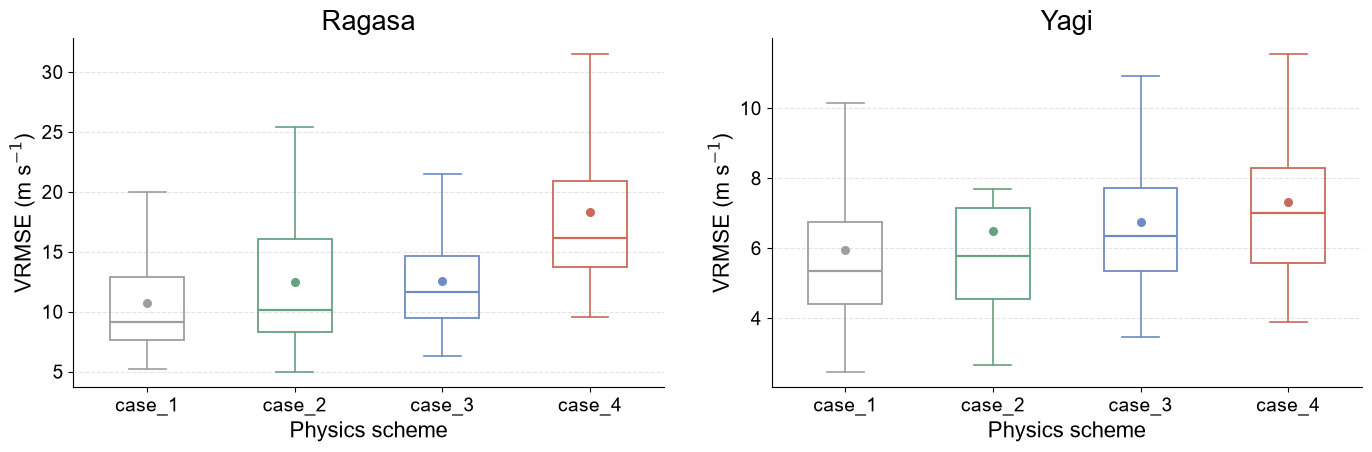

[Saved] E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Supplementary\publish\physics_sensitivity_vrmse_box_ragasa_yagi.tif

[Validated] 16 overall-summary rows, 80 station-group mean rows, and one non-empty 1 × 2 TIFF figure.


WindowsPath('E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Supplementary/publish/physics_sensitivity_vrmse_box_ragasa_yagi.tif')

In [5]:
def save_tiff(fig: mpl.figure.Figure, path: Path) -> None:
    """Save a publication-resolution TIFF, using LZW when available."""
    try:
        fig.savefig(
            path,
            dpi=DPI,
            format="tiff",
            bbox_inches="tight",
            pil_kwargs={"compression": "tiff_lzw"},
        )
    except TypeError:
        fig.savefig(path, dpi=DPI, format="tiff", bbox_inches="tight")


def style_boxplot(boxplot: dict) -> None:
    """Apply the four-scheme publication colors to one boxplot."""
    for index, (color, box) in enumerate(zip(CASE_COLORS, boxplot["boxes"])):
        box.set_facecolor("none")
        box.set_edgecolor(color)
        for artist in boxplot["whiskers"][2 * index : 2 * index + 2]:
            artist.set_color(color)
        for artist in boxplot["caps"][2 * index : 2 * index + 2]:
            artist.set_color(color)
        boxplot["medians"][index].set_color(color)
        boxplot["means"][index].set_markerfacecolor(color)
        boxplot["means"][index].set_markeredgecolor(color)
        boxplot["means"][index].set_zorder(3)


def plot_vrmse_boxplots() -> Path:
    positions = np.arange(len(CASE_ORDER), dtype=float)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14.0, 4.8))

    for ax, (storm_key, metadata) in zip(axes, STORMS.items()):
        table = storm_data[storm_key]["VRMSE"]
        case_values = [
            table.loc[case_key].to_numpy(dtype=float) for case_key in CASE_ORDER
        ]
        if any(
            len(values) != metadata["expected_stations"] for values in case_values
        ):
            raise RuntimeError(f"Unexpected VRMSE sample count for {storm_key}")

        boxplot = ax.boxplot(
            case_values,
            positions=positions,
            widths=0.50,
            patch_artist=True,
            showfliers=False,
            showmeans=True,
            meanline=False,
            boxprops={"linewidth": 1.3},
            medianprops={"linewidth": 1.6},
            whiskerprops={"linewidth": 1.2},
            capprops={"linewidth": 1.2},
            meanprops={
                "marker": "o",
                "markersize": 5.5,
                "markeredgewidth": 1.0,
            },
        )
        style_boxplot(boxplot)

        ax.set_xticks(positions)
        ax.set_xticklabels(CASE_ORDER)
        ax.set_xlabel("Physics scheme")
        ax.set_ylabel("VRMSE (m s$^{-1}$)")
        ax.set_title(metadata["label"])
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.tight_layout(w_pad=2.0)
    output_path = PUBLISH_DIR / "physics_sensitivity_vrmse_box_ragasa_yagi.tif"
    save_tiff(fig, output_path)
    plt.show()
    plt.close(fig)
    print("[Saved]", output_path.resolve())
    return output_path


generated_path = plot_vrmse_boxplots()
if not generated_path.is_file() or generated_path.stat().st_size == 0:
    raise RuntimeError(f"Missing or empty output figure: {generated_path}")

print("\n[Validated] 16 overall-summary rows, 80 station-group mean rows, and one non-empty 1 × 2 TIFF figure.")
generated_path